# **Forgery Detection**

In [1]:
# !pip install kaggle --quiet
!pip install kaggle timm scikit-learn datasets huggingface_hub --quiet

In [2]:
import json
import os
from google.colab import userdata
kaggle_dict={
    "username":userdata.get("KAGGLE_USERNAME"),
    "key":userdata.get('Key')
}

os.makedirs("/root/.kaggle",exist_ok=True)

with open("/root/.kaggle/kaggle.json","w") as f:
  json.dump(kaggle_dict,f)

! chmod 600 /root/.kaggle/kaggle.json

# from google.colab import files
# files.upload()

# import os
# os.makedirs("/roots/.kaggle",exist_ok=True)
# !mv kaggle.json /root/.kaggle/
# !chmod 600 /root/.kaggle/kaggle.json
# print("kaggle auth ready ")

In [3]:
# CASIA v2
!kaggle datasets download -d divg07/casia-20-image-tampering-detection-dataset \
    --unzip -p /content/casia

# CASIA ground truth
!git clone https://github.com/SunnyHaze/CASIA2.0-Corrected-Groundtruth \
    /content/casia/groundtruth



Dataset URL: https://www.kaggle.com/datasets/divg07/casia-20-image-tampering-detection-dataset
License(s): unknown
100% 2.56G/2.56G [00:18<00:00, 152MB/s]

Cloning into '/content/casia/groundtruth'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 38 (delta 10), reused 22 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 1.04 MiB | 4.27 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [4]:
import os
from datasets import load_from_disk

AUTH_DIR = "/content/casia/CASIA2/Au"
TAMP_DIR = "/content/casia/CASIA2/Tp"
MASK_DIR = "/content/casia/CASIA2/CASIA 2 Groundtruth"


print("CASIA authentic :", len(os.listdir(AUTH_DIR)))
print("CASIA tampered  :", len(os.listdir(TAMP_DIR)))
print("Ground truth    :", len(os.listdir(MASK_DIR)))


CASIA authentic : 7492
CASIA tampered  : 5125
Ground truth    : 5123


In [5]:
from datasets import load_dataset

from huggingface_hub import login

# login(token=userdata.get('HF_TOKEN'))

ai_df=load_dataset( "Rajarshi-Roy-research/Defactify_Image_Dataset",
    split="train")    #for training 42k images available


README.md: 0.00B [00:00, ?B/s]

data/validation-00000-of-00002.parquet:   0%|          | 0.00/333M [00:00<?, ?B/s]

data/validation-00001-of-00002.parquet:   0%|          | 0.00/345M [00:00<?, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

data/test-00004-of-00006.parquet:   0%|          | 0.00/574M [00:00<?, ?B/s]

data/test-00005-of-00006.parquet:   0%|          | 0.00/600M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/42000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/45000 [00:00<?, ? examples/s]

In [6]:
# print(ai_df)
print(ai_df[0])
print(ai_df.shape)
# print(ai_df.size)

{'Caption': 'Two tall giraffe standing next to each other on a  field.', 'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x7C7436589C10>, 'Label_A': 0, 'Label_B': 0}
(42000, 4)


In [7]:
# Check unique label values
import pandas as pd

labels_a = [ai_df[i]['Label_A'] for i in range(100)]
labels_b = [ai_df[i]['Label_B'] for i in range(100)]

print("Label_A unique:", set(labels_a))
print("Label_B unique:", set(labels_b))

# Check a few samples to understand labels
for i in range(5):
    sample = ai_df[i]
    print(f"Sample {i}: Label_A={sample['Label_A']} Label_B={sample['Label_B']} Caption={sample['Caption'][:100]}")

Label_A unique: {0, 1}
Label_B unique: {0, 1, 2, 3, 4, 5}
Sample 0: Label_A=0 Label_B=0 Caption=Two tall giraffe standing next to each other on a  field.
Sample 1: Label_A=1 Label_B=1 Caption=Two tall giraffe standing next to each other on a  field.
Sample 2: Label_A=1 Label_B=2 Caption=Two tall giraffe standing next to each other on a  field.
Sample 3: Label_A=1 Label_B=3 Caption=Two tall giraffe standing next to each other on a  field.
Sample 4: Label_A=1 Label_B=4 Caption=Two tall giraffe standing next to each other on a  field.


In [8]:
print(ai_df.features)

{'Caption': Value('string'), 'Image': Image(mode=None, decode=True), 'Label_A': Value('int32'), 'Label_B': Value('int32')}


In [9]:
# # Count real vs AI
# real_count = sum(1 for i in range(len(ai_df)) if ai_df[i]['Label_A'] == 0)
# ai_count   = sum(1 for i in range(len(ai_df)) if ai_df[i]['Label_A'] == 1)

# print(f"Real  : {real_count}")
# print(f"AI    : {ai_count}")
# print(f"Total : {len(ai_df)}")

In [10]:
#  You CAN directly read CASIA images!
# image = cv2.imread("/content/casia/CASIA2/Au/Au_ani_001.jpg")
# image = cv2.imread("/content/casia/CASIA2/Tp/Tp_S_NNN_001.jpg")
# mask  = cv2.imread("/content/casia/groundtruth/Tp_S_NNN_001_gt.png")

# print(image.shape)  # (H, W, 3) ✅
# print(mask.shape)   # (H, W, 3) ✅


In [13]:
#load the SROIE dataset from drive
from google.colab import drive
drive.mount('/content/drive')

print(os.listdir("/content/drive/MyDrive/datasets/sroie"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['archive.zip']


In [14]:
#unzipping sroie
!unzip -q "/content/drive/MyDrive/datasets/sroie/archive.zip" -d /content/sroie

In [15]:
import os
print(os.listdir('/content/sroie/SROIE2019/train/img'))

['X51005442344.jpg', 'X51006620189.jpg', 'X51006619496.jpg', 'X51005568827.jpg', 'X51005663280.jpg', 'X00016469672.jpg', 'X51006913068.jpg', 'X51005757248.jpg', 'X51006392313.jpg', 'X51008099048.jpg', 'X51006557170.jpg', 'X51005757235.jpg', 'X51005719874.jpg', 'X51006008073.jpg', 'X51005447832.jpg', 'X51006619697.jpg', 'X51005441401.jpg', 'X51006557210.jpg', 'X51006867436.jpg', 'X51007225417.jpg', 'X51006619550.jpg', 'X51006332649.jpg', 'X51008042792.jpg', 'X51007339650.jpg', 'X51006557117.jpg', 'X51005676547.jpg', 'X51005719886.jpg', 'X51006913023.jpg', 'X51005677332.jpg', 'X51006328920.jpg', 'X51007231374.jpg', 'X51006912960.jpg', 'X51006619854.jpg', 'X51006556830.jpg', 'X51006555780.jpg', 'X51007339117.jpg', 'X51006414485.jpg', 'X51007339164.jpg', 'X51008114281.jpg', 'X51006913007.jpg', 'X51005741944.jpg', 'X51007339112.jpg', 'X51005268200.jpg', 'X51005711453.jpg', 'X51005301661.jpg', 'X51005200938.jpg', 'X51005745190.jpg', 'X51005677329.jpg', 'X51007103691.jpg', 'X51008114216.jpg',

In [16]:
import os
import pandas as pd
from tqdm import tqdm

AUTH_DIR = "/content/casia/CASIA2/Au"
TAMP_DIR = "/content/casia/CASIA2/Tp"
MASK_DIR = "/content/casia/CASIA2/CASIA 2 Groundtruth"
SROIE_DIRS = [
    "/content/sroie/SROIE2019/train/img",  # 626 authentic receipts
    "/content/sroie/SROIE2019/test/img",   # 347 authentic receipts
]


# Build mask lookup — strip _gt for matching
mask_lookup = {}
for f in os.listdir(MASK_DIR):
    base = f.replace("_gt.png", "")  # remove _gt suffix
    mask_lookup[base] = os.path.join(MASK_DIR, f)

records = []

#CASIA Authentic
for f in os.listdir(AUTH_DIR):
    if not f.lower().endswith((".jpg",".png",".tif",".bmp")):
        continue
    records.append({
        "file_id"        : f.rsplit(".",1)[0],
        "image_path"     : os.path.join(AUTH_DIR, f),
        "mask_path"      : None,
        "is_forged"      : 0,
        "forgery_type"   : "none",
        "source_dataset" : "CASIA_v2"
    })

# Tampered
for f in os.listdir(TAMP_DIR):
    if not f.lower().endswith((".jpg",".png",".tif",".bmp")):
        continue

    base         = f.rsplit(".",1)[0]
    mask_path    = mask_lookup.get(base, None)  # lookup using base name
    forgery_type = "copy_move" if "_CM_" in f or "CRN" in f \
                   else "splicing" if "_S_" in f \
                   else "unknown"

    records.append({
        "file_id"        : base,
        "image_path"     : os.path.join(TAMP_DIR, f),
        "mask_path"      : mask_path,
        "is_forged"      : 1,
        "forgery_type"   : forgery_type,
        "source_dataset" : "CASIA_v2"
    })



# Adding ai_dataset to master csv
real_count=0
ai_count=0
target=2500 #as we have imbalanced dataset so we taking 7k rows from each ai and real
#its was domination so reduced to 2k

for i , sample in enumerate(tqdm(ai_df, desc='processing')):
  label=sample['Label_A']

  if label == 0 and real_count<target:

    records.append({
        "file_id"       :f'defactify_real_{i:05d}',
        "image_path"        :f"defactify_index_{i}",
        'mask_path'         :None,
        "is_forged"         :0,
        "forgery_type"      :"none",
        "source_dataset"    :"DEFACTIFY"
    })
    real_count+=1


  elif label==1 and ai_count<target:
    records.append({
        "file_id"  : f"defactify_ai_{i:05d}",
        "image_path" :f"defactify_index_{i}",
        "mask_path" :None,
        "is_forged" :1,
        "forgery_type" : "ai_generated",
        "source_dataset" : "DEFACTIFY"
    })

    ai_count+=1

  if ai_count >= target and real_count>=target :
    break

print(f'Real added : {real_count}')
print(f'AI added : {ai_count}')

# ------------------------------------------------------------------------
#SROIE PRESCIPTION
for img_dir in SROIE_DIRS:
    if not os.path.exists(img_dir):
        continue
    for file in os.listdir(img_dir):
      if file.lower().endswith(".jpg"):

        img_path = os.path.join(img_dir, file)

        records.append({
            "file_id": f"sroie_{file}",
            "image_path": img_path,
            "mask_path": None,
            "is_forged": 0,
            "forgery_type": "none",
            "source_dataset": "SROIE"
        })


sroie_df=pd.DataFrame(records)
print("SROIE Samples:",len(sroie_df))


# Build dataframe
df = pd.DataFrame(records)
df.to_csv("/content/master_labels.csv", index=False)


print(f"Total records : {len(df)}")
print(f"Authentic     : {len(df[df.is_forged==0])}")
print(f"Forged        : {len(df[df.is_forged==1])}")
print(f"With mask     : {df.mask_path.notna().sum()}")
print(f"\nForgery types:\n{df.forgery_type.value_counts()}")
print(f"\nSources:\n{df.source_dataset.value_counts()}")


processing:  36%|███▌      | 14994/42000 [00:49<01:28, 304.99it/s]


Real added : 2500
AI added : 2500
SROIE Samples: 18587
Total records : 18587
Authentic     : 10964
Forged        : 7623
With mask     : 4981

Forgery types:
forgery_type
none            10964
splicing         3929
ai_generated     2500
unknown           662
copy_move         532
Name: count, dtype: int64

Sources:
source_dataset
CASIA_v2     12614
DEFACTIFY     5000
SROIE          973
Name: count, dtype: int64


In [17]:
import os
print(os.path.exists("/content/ai_df"))
print(os.listdir("/content"))

False
['.config', 'drive', 'master_labels.csv', 'sroie', 'casia', 'sample_data']


In [18]:
import torch
print(torch.cuda.is_available())

True


Synthetic Forgery for Sorie Datasets

In [19]:
import cv2
import numpy as np
import random

# Text Overlay(core fucntino)
def text_overlay(img):
  h, w, _=img.shape
  mask=np.zeros((h,w),dtype=np.uint8)

  #random position
  x=random.randint(0,w//2)
  y=random.randint(0,h//2)
  text=str(random.randint(100,9999)) #fake number

  font=cv2.FONT_HERSHEY_SIMPLEX
  font_scale=random.uniform(0.5,1.2)
  thickness=random.randint(1,2)

  #get the size to draw accurate mask
  (tw,th),_ =cv2.getTextSize(text , font , font_scale ,thickness)
  y=max(th,y) #prevent negatice index if y < th
  mask[y-th:y+5, x:x+tw]=255 # mask text region

  cv2.putText(img,text,(x,y),font,font_scale,(0,0,0),thickness)

  return img ,mask



Amount Tampering(focused)

In [20]:
def amount_tampering(img):
  h,w,_=img.shape
  mask=np.zeros((h,w),dtype=np.uint8)

  # assume bottom area has totals
  x=random.randint(w//3,w-100)
  y=random.randint(h//2,h-50)
  fake_amount=str(random.randint(1000,9999))

  font=cv2.FONT_HERSHEY_SIMPLEX
  font_scale=0.8
  thickness=2

  #get the sizee for accurate mask
  (tw, th), _ =cv2.getTextSize(fake_amount ,font, font_scale, thickness)
  y = max(th, y)  # prevent negative index
  mask[y-th:y+5 , x:x+tw]=255

  cv2.putText(img,fake_amount,(x,y),font, font_scale,
              (0,0,0),thickness)

  return img ,mask


Blur Region

In [21]:
def blur_region(img):
  h,w,_=img.shape
  mask= np.zeros((h,w),dtype=np.uint8)

  x1=random.randint(0,w//2)
  y1=random.randint(0,h//2)

  x2=x1 + random.randint(50,150)
  y2=y1 + random.randint(50,150)

  # clamp to image bond
  x2=min(x2,w)
  y2=min(y2,h)


  img[y1:y2,x1:x2]=cv2.GaussianBlur(
      img[y1:y2,x1:x2],(15,15),0
  )


  mask[y1:y2 , x1:x2 ] = 255 # mark blurred region

  return img , mask

In [22]:
import uuid

def generate_fake(img_path, save_dir):
    img = cv2.imread(img_path)

    if img is None:
        return None, None , None

    choice = random.choice([
        "text_overlay",
        "amount_tampering",
        "blur_region"
    ])

    if choice == "text_overlay":
        img, mask = text_overlay(img)
    elif choice == "amount_tampering":
        img, mask = amount_tampering(img)
    else:
        img, mask = blur_region(img)

    uid       = str(uuid.uuid4())
    save_path = os.path.join(save_dir, f"fake_{uid}.jpg")
    mask_path = os.path.join(save_dir, f"mask_{uid}.png")  #  PNG not JPG

    cv2.imwrite(save_path, img)
    cv2.imwrite(mask_path, mask)  #  was `img`

    return save_path, choice, mask_path

Generating Synthetic Dataset -1

In [23]:
# adding the synthetically generated forged to master dataset

import uuid
import os
import pandas as pd

#---output directory for fake sroie images
save_dir="/content/sroie_fake"
os.makedirs(save_dir,exist_ok=True)

#get sroie rows from mster csv
master_df=pd.read_csv("/content/master_labels.csv")
sroie_df=master_df[master_df['source_dataset']=='SROIE'].reset_index(drop=True)
print(f"SROIE authentic images available :{len(sroie_df)}")


# generating 1100 fake SROIE IMAGES

synthetic_records=[]

for _, row in tqdm(sroie_df.sample(min(1100,len(sroie_df)),random_state=42).iterrows(),desc="generating SROIE Fakes",total=min(1000,len(sroie_df))):
  fake_path,f_type, mask_path =generate_fake(row['image_path'],save_dir)

  if fake_path is None:
    continue


  synthetic_records.append({
            "file_id":f"sroie_fake_{os.path.basename(fake_path)}",
            "image_path":fake_path,
            "mask_path":mask_path,
            "is_forged":1,
            "forgery_type":'text_tamper',
            "source_dataset":"SROIE_SYNTHETIC"

        })

print(f"Genrated : {len(synthetic_records)} fake SROIE images")

#merge into master csv
synthetic_df=pd.DataFrame(synthetic_records)
final_df=pd.concat([master_df,synthetic_df],ignore_index=True)

final_df=final_df[final_df.forgery_type !='unknown'].reset_index(drop=True) #removing images of type unkown

final_df.to_csv('/content/master_labels.csv',index=False)

print(f"\n updated master CSV:")
print(f'Total : {len(final_df)}')
print(f"Authentic : {len(final_df[final_df.is_forged==0])}")
print(f'Forged : {len(final_df[final_df.is_forged==1])}')
print(f"With mask : {final_df.mask_path.notna().sum()}")
print(f'\n Sources :\n {final_df.source_dataset.value_counts()}')
print(f'\n forgery types:\n {final_df.forgery_type.value_counts()}')



SROIE authentic images available :973


generating SROIE Fakes: 100%|██████████| 973/973 [01:18<00:00, 12.47it/s]


Genrated : 973 fake SROIE images

 updated master CSV:
Total : 18898
Authentic : 10964
Forged : 7934
With mask : 5317

 Sources :
 source_dataset
CASIA_v2           11952
DEFACTIFY           5000
SROIE                973
SROIE_SYNTHETIC      973
Name: count, dtype: int64

 forgery types:
 forgery_type
none            10964
splicing         3929
ai_generated     2500
text_tamper       973
copy_move         532
Name: count, dtype: int64


# **Dataset Distribution**

none         : 13191  → CASIA auth(7492)  + Defactify_real(2500 - 1) + SROIE

ai_generated :  2500  → Defactify fake

splicing     :  4996  → CASIA(3930) + Synthetic(1066)

copy_move    :  1599  → CASIA(533)  + Synthetic(1066)  ← needs +1400

text_tamper  :  1066  → Synthetic only                 ← needs +1934



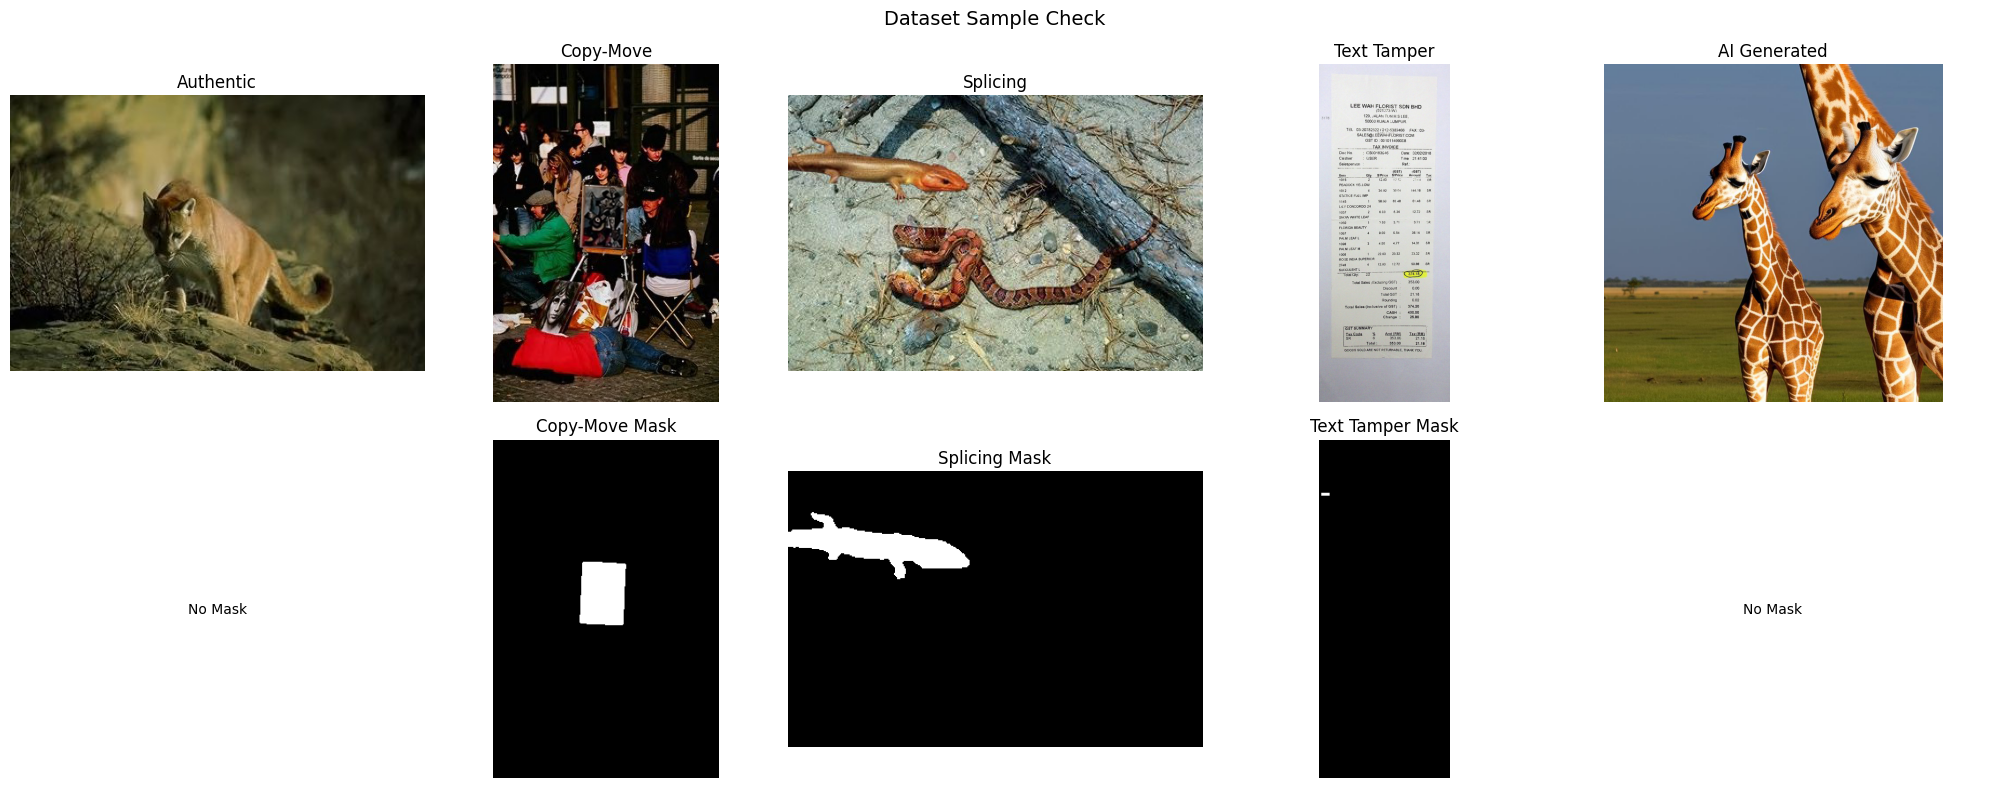

Sanity check complete ✓


In [24]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd


df = pd.read_csv("/content/master_labels.csv")

def load_image(image_path):
    """Load image from disk or HuggingFace dataset index"""
    image_path = str(image_path)


    if image_path.startswith("defactify_index_"):
        i     = int(image_path.split("_")[-1])
        image = ai_df[i]["Image"].convert("RGB")
        return np.array(image)

    else:
        img = cv2.imread(image_path)
        if img is None:
            return np.zeros((224, 224, 3), dtype=np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ── Define one sample per forgery type ───────────────────────────
authentic   = df[df.forgery_type == "none"].iloc[0]
copy_move   = df[df.forgery_type == "copy_move"].iloc[0]
splicing    = df[df.forgery_type == "splicing"].iloc[0]
text_tamp   = df[df.forgery_type == "text_tamper"].iloc[0]
ai_generate = df[df.forgery_type == "ai_generated"].iloc[0]

samples = [authentic, copy_move, splicing, text_tamp, ai_generate]
titles  = ["Authentic", "Copy-Move", "Splicing", "Text Tamper", "AI Generated"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Dataset Sample Check", fontsize=14)

for i, (sample, title) in enumerate(zip(samples, titles)):
    img = load_image(sample["image_path"])
    axes[0][i].imshow(img)
    axes[0][i].set_title(title)
    axes[0][i].axis("off")

    if pd.notna(sample["mask_path"]):
        mask = cv2.imread(sample["mask_path"], cv2.IMREAD_GRAYSCALE)
        axes[1][i].imshow(mask, cmap="gray")
        axes[1][i].set_title(f"{title} Mask")
    else:
        axes[1][i].text(0.5, 0.5, "No Mask", ha="center", va="center")
    axes[1][i].axis("off")

plt.tight_layout()
plt.savefig("/content/dataset_check.png")
plt.show()
print("Sanity check complete ✓")

In [25]:
import pandas as pd
df=pd.read_csv('master_labels.csv')
print(df.head())
print(df.is_forged.value_counts())

        file_id                                 image_path mask_path  \
0  Au_ani_30229  /content/casia/CASIA2/Au/Au_ani_30229.jpg       NaN   
1  Au_cha_00004  /content/casia/CASIA2/Au/Au_cha_00004.jpg       NaN   
2  Au_nat_30524  /content/casia/CASIA2/Au/Au_nat_30524.jpg       NaN   
3  Au_sec_30315  /content/casia/CASIA2/Au/Au_sec_30315.jpg       NaN   
4  Au_ani_10121  /content/casia/CASIA2/Au/Au_ani_10121.jpg       NaN   

   is_forged forgery_type source_dataset  
0          0         none       CASIA_v2  
1          0         none       CASIA_v2  
2          0         none       CASIA_v2  
3          0         none       CASIA_v2  
4          0         none       CASIA_v2  
is_forged
0    10964
1     7934
Name: count, dtype: int64


In [26]:
!pip install timm scikit-learn --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


**Dataset Loader**

In [27]:
from datasets import load_from_disk


class ForgeryDataset(Dataset):
    def __init__(self, df, transform=None, mask_size=(128, 128)):
        # Only use rows with valid image paths
        self.df         = df.reset_index(drop=True)
        self.transform  = transform
        self.mask_size  = mask_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Load image ───────────────────────────────────────────
        try:

            if str(row["image_path"]).startswith("defactify_index_"):
              # Load from HuggingFace dataset Defactify
              i     = int(str(row["image_path"]).split("_")[-1])
              image = ai_df[i]["Image"].convert("RGB")
              image = np.array(image) #PIL (400, 300)  → numpy (300, 400, 3)

            else:
                image = cv2.imread(row["image_path"])
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            image = cv2.resize(image, (224, 224)) #(300, 400, 3) → (224, 224, 3) ✅
            image = Image.fromarray(image) #numpy → PIL

            if self.transform: # augment + ToTensor + Normalize → (3,224,224)
                image = self.transform(image) ## PIL (224,224) → tensor (3, 224, 224)

        except Exception:
            image = torch.zeros(3, 224, 224) #ResNet50 was originally trained on ImageNet with 224×224 images

        # ── Load mask ────────────────────────────────────────────
        try:
            if pd.notna(row["mask_path"]):
                mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
                if mask is not None:

                  mask = cv2.resize(mask, self.mask_size)
                  mask = torch.tensor(mask / 255.0, dtype=torch.float32).unsqueeze(0)

                else:
                  mask=torch.zeros(1,*self.mask_size) #mask all zeros (no forgery region) in case image failed to load
            else:
                mask = torch.zeros(1, *self.mask_size)
        except Exception:
            mask = torch.zeros(1, *self.mask_size)

        # ── Labels ───────────────────────────────────────────────
        is_forged    = torch.tensor(row["is_forged"], dtype=torch.float32)
        has_mask     = torch.tensor(1.0 if pd.notna(row["mask_path"]) else 0.0)
        type_label=torch.tensor(
            TYPE_MAP.get(row['forgery_type'],0),
            dtype=torch.long
        )

        return image, mask, is_forged, has_mask , type_label

CASIA path:
numpy(BGR) → cvtColor → numpy(RGB)
→ resize → PIL → transform → tensor

HuggingFace path (your suggestion):
PIL → PIL.resize() → transform → tensor ✅

**Model Architecture**

In [28]:
import torch
import torch.nn as nn
import timm
import numpy as np
from PIL import Image
import io

# ── Choose your backbone here ─────────────────────────────────────
# "efficientnet_b4"     — your current model, good baseline
# "resnet50d"           — simpler, faster, easier to debug
# "convnext_small"      — modern CNN, strong on texture forgeries
# "swin_small_patch4_window7_224"  — transformer, best for AI-generated detection
BACKBONE_NAME = "efficientnet_b4"

class ForgeryDetector(nn.Module):
    def __init__(self, backbone_name=BACKBONE_NAME):
        super().__init__()

        # ── Backbone — swappable ──────────────────────────────────
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            features_only=True,
            out_indices=[1, 2, 3, 4]
        )

        # ── Auto-detect output channels from whatever backbone ────
        with torch.no_grad():
            dummy     = torch.zeros(1, 3, 224, 224)
            features  = self.backbone(dummy)
            last_feat = features[-1]
            channels  = last_feat.shape[1]
            print(f"Backbone        : {backbone_name}")
            print(f"Output channels : {channels}")
            print(f"Feature shape   : {last_feat.shape}")

        # ── ELA Branch ───────────────────────────────────────────
        self.ela_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )

        # ── Classification Head ───────────────────────────────────
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) #Combine- CNN features (global understanding)
        self.classifier  = nn.Sequential(                  #ELA features (artifact detection)
            nn.Flatten(),
            nn.Linear(channels + 64, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1) #logit → sigmoid → fake / real
        )

        # ── Forgery Type Head ─────────────────────────────────────
        self.type_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 5)
        )

        # ── Segmentation Head ─────────────────────────────────────
        self.seg_head = nn.Sequential(
            nn.Conv2d(channels, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1) #(1, H', W')
        )

    def compute_ela(self, x, quality=90): #x → (B, 3, 224, 224)
        ela_imgs = []
        for img in x:
            try:
                img_np  = (
                    img.permute(1, 2, 0).cpu().float().numpy() * 255
                ).astype(np.uint8) #Tensor → NumPy format
                pil_img = Image.fromarray(img_np)
                buf = io.BytesIO()
                pil_img.save(buf, format="JPEG", quality=quality) #Recompress image
                buf.seek(0)
                recompressed = np.array(Image.open(buf)).astype(np.float32)
                ela = np.abs(img_np.astype(np.float32) - recompressed) #Normalize
                if ela.max() > 0:
                    ela = ela / ela.max() #Normalize
                ela_imgs.append(torch.tensor(ela).permute(2, 0, 1).float())
            except Exception:
                ela_imgs.append(torch.zeros(3, 224, 224))
        return torch.stack(ela_imgs).to(x.device)

    def forward(self, x):
        features  = self.backbone(x)
        last_feat = features[-1]

        ela      = self.compute_ela(x)
        ela_feat = self.ela_conv(ela)

        pooled   = self.global_pool(last_feat)
        pooled   = pooled.view(pooled.size(0), -1)
        combined = torch.cat([pooled, ela_feat], dim=1)

        cls_out  = self.classifier(combined).squeeze(1)
        type_out = self.type_head(combined)
        seg_out  = self.seg_head(last_feat)

        return cls_out, type_out, seg_out


import gc
gc.collect()
torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = ForgeryDetector(BACKBONE_NAME).to(DEVICE)

print(f"\nModel ready ✓")
print(f"Device     : {DEVICE}")
print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Backbone        : efficientnet_b4
Output channels : 448
Feature shape   : torch.Size([1, 448, 7, 7])

Model ready ✓
Device     : cuda
Parameters : 17,898,575


 These parameters store knowledge about edges, textures, shapes, and higher-level features extracted during preprocessing and training.

Transform + DataLoaders

In [29]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# Forgery type → integer mapping
TYPE_MAP = {
    "none"        : 0,
    "copy_move"   : 1,
    "splicing"    : 2,
    "text_tamper" : 3,
    "ai_generated": 4,
}

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Load CSV ──────────────────────────────────────────────────────
df = pd.read_csv("/content/master_labels.csv")




print(df["is_forged"].value_counts())
print(df["forgery_type"].value_counts())
print(df["source_dataset"].value_counts())

# Split disk vs defactify only
disk_df = df[
    ~df["image_path"].str.startswith("defactify_index_", na=False)
]

defactify_df = df[
    df["image_path"].str.startswith("defactify_index_", na=False)
]

# Split disk
train_disk, val_disk = train_test_split(
    disk_df, test_size=0.2,
    stratify=disk_df["is_forged"],
    random_state=42
)

# Split defactify
train_def, val_def = train_test_split(
    defactify_df, test_size=0.1,
    stratify=defactify_df["is_forged"],
    random_state=42
)

# Combine (NO RVL)
train_df = pd.concat(
    [train_disk, train_def],
    ignore_index=True
).copy()

val_df = pd.concat(
    [val_disk, val_def],
    ignore_index=True
).copy()

print(f"\nTrain : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"\nVal distribution:")
print(val_df["is_forged"].value_counts())
print(f"\nVal by source:")
print(val_df["source_dataset"].value_counts())
print(f"\nTrain distribution:")
print(train_df["is_forged"].value_counts())


# ── Fix 3: Add mild authentic oversampling ────────────────────────
# type_loss fires only on forged → forged gets more gradient
# 1.5x authentic boost compensates
from torch.utils.data import WeightedRandomSampler

n_authentic = len(train_df[train_df.is_forged == 0])
n_forged    = len(train_df[train_df.is_forged == 1])

train_df["sample_weight"] = train_df["is_forged"].map({
    0: (1.0 / n_authentic) * 2.5,   # ← was 1.5, raise to 2.5
    1: (1.0 / n_forged)
})

# ── Datasets ─────────────────────────────────────────────────────
train_dataset = ForgeryDataset(train_df, transform=transform_train)
val_dataset   = ForgeryDataset(val_df,   transform=transform_val)

weights = torch.tensor(train_df["sample_weight"].values, dtype=torch.float)
sampler = WeightedRandomSampler(
    weights=weights,
    num_samples=len(weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,         # ← back to sampler with 1.5x authentic boost
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"\nSample weight check:")
print(f"Authentic weight : {train_df[train_df.is_forged==0]['sample_weight'].mean():.8f}")
print(f"Forged weight    : {train_df[train_df.is_forged==1]['sample_weight'].mean():.8f}")

is_forged
0    10964
1     7934
Name: count, dtype: int64
forgery_type
none            10964
splicing         3929
ai_generated     2500
text_tamper       973
copy_move         532
Name: count, dtype: int64
source_dataset
CASIA_v2           11952
DEFACTIFY           5000
SROIE                973
SROIE_SYNTHETIC      973
Name: count, dtype: int64

Train : 15618
Val   : 3280

Val distribution:
is_forged
0    1943
1    1337
Name: count, dtype: int64

Val by source:
source_dataset
CASIA_v2           2364
DEFACTIFY           500
SROIE_SYNTHETIC     211
SROIE               205
Name: count, dtype: int64

Train distribution:
is_forged
0    9021
1    6597
Name: count, dtype: int64

Train batches : 976
Val batches   : 205

Sample weight check:
Authentic weight : 0.00027713
Forged weight    : 0.00015158


Training loops

In [30]:
from torch.cuda.amp import autocast, GradScaler

scaler             = GradScaler()
ACCUMULATION_STEPS = 4

# ── Focal Loss ────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.90, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(
                    inputs, targets, reduction="none")
        pt    = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

cls_criterion = FocalLoss(alpha=0.60, gamma=2.0)
#  was 0.85
# lower alpha = more weight on authentic (negative class)
# this directly penalises the model for missing authentic images
seg_criterion = nn.BCEWithLogitsLoss()

# ── Weighted type criterion — 5 classes to match type_head ───────
type_counts_all  = df["forgery_type"].value_counts().to_dict()
num_type_classes = 5
total_samples    = len(df)

type_weights = torch.tensor([
    total_samples / (num_type_classes * type_counts_all.get("none",         1)),
    total_samples / (num_type_classes * type_counts_all.get("copy_move",    1)),
    total_samples / (num_type_classes * type_counts_all.get("splicing",     1)),
    total_samples / (num_type_classes * type_counts_all.get("text_tamper",  1)),
    total_samples / (num_type_classes * type_counts_all.get("ai_generated", 1)),
], dtype=torch.float).to(DEVICE)

type_criterion = nn.CrossEntropyLoss(weight=type_weights)
print("Type weights:", type_weights)  # should print 5 values

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    optimizer.zero_grad()

    for i, (images, masks, labels, has_mask, type_labels) in enumerate(tqdm(loader, desc="Training")):
        images      = images.to(DEVICE)
        masks       = masks.to(DEVICE)
        labels      = labels.to(DEVICE)
        has_mask    = has_mask.to(DEVICE)
        type_labels = type_labels.to(DEVICE)

        with autocast():
            cls_out, type_out, seg_out = model(images)
            cls_loss = cls_criterion(cls_out, labels)

            type_loss  = torch.tensor(0.0).to(DEVICE)
            forged_idx = labels.bool()
            if forged_idx.sum() > 0:
                type_loss = type_criterion(     # ← no shifting, labels 0-4 match 5 outputs
                    type_out[forged_idx],
                    type_labels[forged_idx]
                )

            seg_loss = torch.tensor(0.0).to(DEVICE)
            mask_idx = has_mask.bool()
            if mask_idx.sum() > 0:
                seg_out_masked = seg_out[mask_idx]
                target_masks   = nn.functional.interpolate(
                    masks[mask_idx],
                    size=seg_out_masked.shape[2:],
                    mode="bilinear", align_corners=False
                )
                seg_loss = seg_criterion(seg_out_masked, target_masks)

            loss = (cls_loss + 0.1 * type_loss + 0.1 * seg_loss) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * ACCUMULATION_STEPS
        preds       = (torch.sigmoid(cls_out) > 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if i % 50 == 0:
            torch.cuda.empty_cache()

    return total_loss / len(loader), correct / total


def val_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, masks, labels, has_mask, type_labels in tqdm(loader, desc="Validation"):
            images      = images.to(DEVICE)
            masks       = masks.to(DEVICE)
            labels      = labels.to(DEVICE)
            has_mask    = has_mask.to(DEVICE)
            type_labels = type_labels.to(DEVICE)

            with autocast():
                cls_out, type_out, seg_out = model(images)
                cls_loss = cls_criterion(cls_out, labels)

                type_loss  = torch.tensor(0.0).to(DEVICE)
                forged_idx = labels.bool()
                if forged_idx.sum() > 0:
                    type_loss = type_criterion(     # ← no shifting here either
                        type_out[forged_idx],
                        type_labels[forged_idx]
                    )

                seg_loss = torch.tensor(0.0).to(DEVICE)
                mask_idx = has_mask.bool()
                if mask_idx.sum() > 0:
                    seg_out_masked = seg_out[mask_idx]
                    target_masks   = nn.functional.interpolate(
                        masks[mask_idx],
                        size=seg_out_masked.shape[2:],
                        mode="bilinear", align_corners=False
                    )
                    seg_loss = seg_criterion(seg_out_masked, target_masks)

            loss        = cls_loss + 0.1 * type_loss + 0.1 * seg_loss
            total_loss += loss.item()
            preds       = (torch.sigmoid(cls_out) > 0.5).float()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

print("Training functions ready ✓")

Type weights: tensor([0.3447, 7.1045, 0.9620, 3.8845, 1.5118], device='cuda:0')
Training functions ready ✓


**Run Training**

In [31]:
import torch.optim as optim
from torch.optim.lr_scheduler import SequentialLR , LinearLR, ReduceLROnPlateau

# ── Optimizer — differential LRs ─────────────────────────────────
optimizer = optim.AdamW([
    {"params": model.backbone.parameters(),  "lr": 5e-5},
    {"params": model.classifier.parameters(),"lr": 2e-4},
    {"params": model.type_head.parameters(), "lr": 2e-4},
    {"params": model.seg_head.parameters(),  "lr": 2e-4},
    {"params": model.ela_conv.parameters(),  "lr": 2e-4},
], weight_decay=1e-4)

# ── Warmup for first 3 epochs ─────────────────────────────────────
warmup_scheduler = LinearLR(
    optimizer,
    start_factor=0.1,   # starts at 10% of base LR (5e-6 for backbone)
    end_factor=1.0,     # ramps up to full LR by epoch 3
    total_iters=3
)

# ── Plateau after warmup ──────────────────────────────────────────
plateau_scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

WARMUP_EPOCHS = 3
print("Optimizer + schedulers ready ✓")

Optimizer + schedulers ready ✓


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Epoch 1/14


Validation: 100%|██████████| 205/205 [00:50<00:00,  4.07it/s]


[Warmup]  LR: 2.00e-05
Train Loss: 0.2680 | Train Acc: 0.6799
Val Loss  : 0.2309   | Val Acc  : 0.5945
Model saved to drive
Best model saved ✓  val_acc: 0.5945

Epoch 2/14


Validation: 100%|██████████| 205/205 [00:44<00:00,  4.60it/s]


[Warmup]  LR: 3.50e-05
Train Loss: 0.1959 | Train Acc: 0.7027
Val Loss  : 0.1885   | Val Acc  : 0.6052
Model saved to drive
Best model saved ✓  val_acc: 0.6052

Epoch 3/14


...

[Plateau] LR: 5.00e-05
Train Loss: 0.1232 | Train Acc: 0.7799
Val Loss  : 0.1521   | Val Acc  : 0.6774
Model saved to drive
Best model saved ✓  val_acc: 0.6774

Epoch 13/14


Validation: 100%|██████████| 205/205 [00:44<00:00,  4.59it/s]


[Plateau] LR: 5.00e-05
Train Loss: 0.1196 | Train Acc: 0.7807
Val Loss  : 0.1508   | Val Acc  : 0.6768
No improvement 1/4

Epoch 14/14


Validation: 100%|██████████| 205/205 [00:44<00:00,  4.58it/s]


[Plateau] LR: 5.00e-05
Train Loss: 0.1192 | Train Acc: 0.7866
Val Loss  : 0.1573   | Val Acc  : 0.6665
No improvement 2/4

Training Complete. Best Val Accuracy: 0.6774


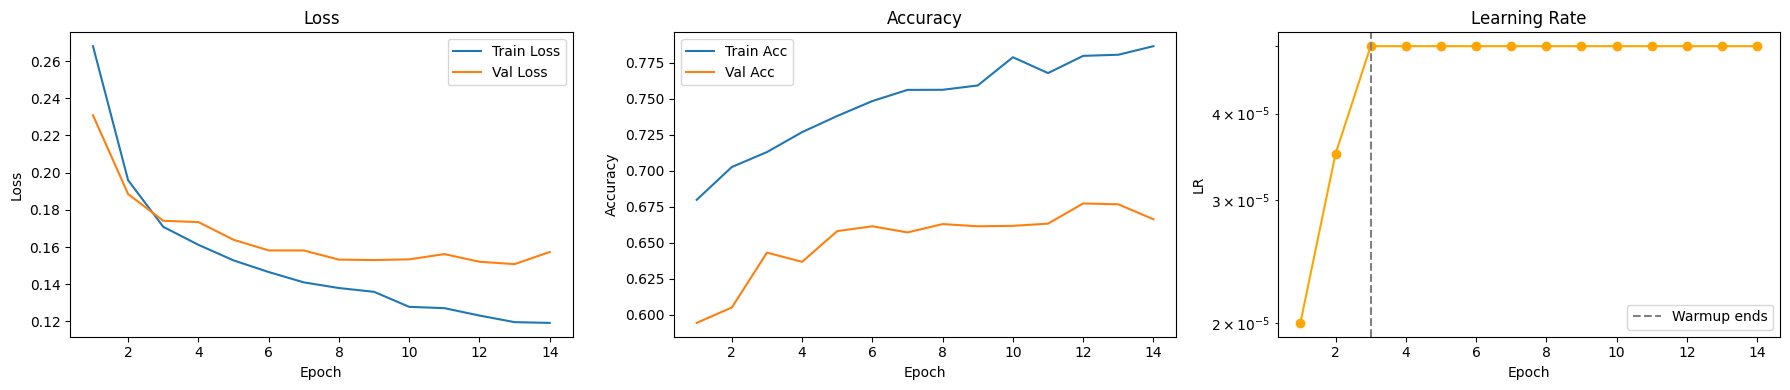

Plot saved ✓


In [32]:
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

os.makedirs("/content/drive/MyDrive/forgery_detection-1",
            exist_ok=True)

EPOCHS        = 14
best_val      = 0
history       = []
patience      = 4       # stop if no improvement for 5 epochs
no_improve    = 0       # counter

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_loss,   val_acc   = val_epoch(model, val_loader)


    # ── LR schedule — warmup first 3 epochs, plateau after ───────
    if epoch < WARMUP_EPOCHS:
        warmup_scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"[Warmup]  LR: {current_lr:.2e}")
    else:
        plateau_scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"[Plateau] LR: {current_lr:.2e}")

    history.append({
        "epoch"      : epoch + 1,
        "train_loss" : train_loss,
        "train_acc"  : train_acc,
        "val_loss"   : val_loss,
        "val_acc"    : val_acc,
        "lr"         : current_lr     #track LR per epoch
    })

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f}   | Val Acc  : {val_acc:.4f}")

    # ── Save best model ───────────────────────────────────────────
    if val_acc > best_val:
        best_val   = val_acc
        no_improve = 0

        torch.save(model.state_dict(),
        "/content/drive/MyDrive/forgery_detection-1/model_weights.pth"
        )

        print('Model saved to drive')
        print(f"Best model saved ✓  val_acc: {val_acc:.4f}")
    else:
        no_improve += 1
        print(f"No improvement {no_improve}/{patience}")

    # ── Early stopping ────────────────────────────────────────────
    if no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining Complete. Best Val Accuracy: {best_val:.4f}")

# ── Plot training history ─────────────────────────────────────────
history_df = pd.DataFrame(history)

fig, axes  = plt.subplots(1, 3, figsize=(18, 4))  #3rd plot added

# Loss plot
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy plot
axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train Acc")
axes[1].plot(history_df["epoch"], history_df["val_acc"],   label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["lr"], color="orange", marker="o")
axes[2].axvline(x=WARMUP_EPOCHS, color="gray", linestyle="--", label="Warmup ends")
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].set_yscale("log")          # log scale shows LR changes clearly
axes[2].legend()

plt.tight_layout()
plt.savefig("/content/training_history.png")
plt.show()
print("Plot saved ✓")


**Loading the Model For Prediction**

Evaluation metrics

Evaluating: 100%|██████████| 205/205 [00:44<00:00,  4.59it/s]


              precision    recall  f1-score   support

   Authentic       0.80      0.69      0.74      1943
      Forged       0.62      0.75      0.68      1337

    accuracy                           0.71      3280
   macro avg       0.71      0.72      0.71      3280
weighted avg       0.73      0.71      0.71      3280



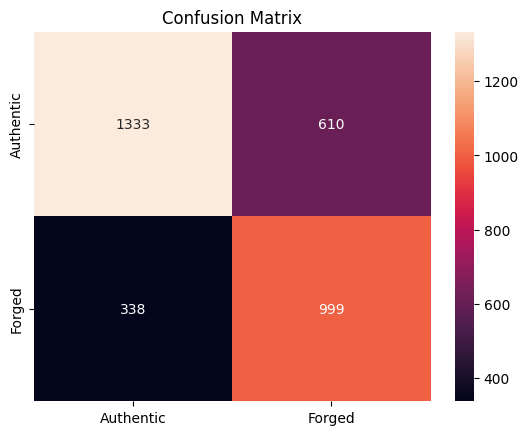

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, masks, labels, has_mask, type_labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        with autocast():
            cls_out, type_out, _ = model(images)
        preds = (torch.sigmoid(cls_out) > 0.40).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=["Authentic", "Forged"]
))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Authentic", "Forged"],
            yticklabels=["Authentic", "Forged"])
plt.title("Confusion Matrix")
plt.savefig("/content/confusion_matrix.png")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')  #only when needed to load the weights

In [34]:
import torch
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torch.cuda.amp import autocast

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── FIXED: load weights only, not full model ──────────────────────
model = ForgeryDetector().to(DEVICE)
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/forgery_detection-1/model_weights.pth",
        map_location=DEVICE
    )
)
model.eval()
print("Model loaded ✓")

# ── FIXED: 5 entries only, no "unknown" ──────────────────────────
TYPE_MAP_INV = {
    0: "none",
    1: "copy_move",
    2: "splicing",
    3: "text_tamper",
    4: "ai_generated",
}

FORGERY_DESCRIPTIONS = {
    "copy_move"   : "A region was copied and pasted within the same document",
    "splicing"    : "A region from another document was inserted here",
    "text_tamper" : "A text field was erased and rewritten",
    "ai_generated": "This image was entirely generated by AI",
    "none"        : "No forgery detected"
}

# ── Image loader — handles disk + HuggingFace indices ─────────────
def load_image_for_predict(image_path):
    image_path = str(image_path)

    if image_path.startswith("defactify_index_"):
        i     = int(image_path.split("_")[-1])
        image = ai_df[i]["Image"].convert("RGB")
        return np.array(image)

    else:
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ── Predict ───────────────────────────────────────────────────────
def predict(image_path, threshold=0.50):   # ← FIXED: was 0.45

    image_rgb = load_image_for_predict(image_path)
    image_rgb = cv2.resize(image_rgb, (224, 224))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    tensor = transform(Image.fromarray(image_rgb)).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with autocast():
            cls_out, type_out, seg_out = model(tensor)

    confidence = float(torch.sigmoid(cls_out).item())
    confidence = max(0.0, min(1.0, confidence))
    is_forged  = confidence > threshold

    if is_forged:
        type_idx     = torch.argmax(type_out, dim=1).item()
        forgery_type = TYPE_MAP_INV.get(type_idx, "none")  # ← fallback to "none" not "unknown"
    else:
        forgery_type = "none"

    description = FORGERY_DESCRIPTIONS[forgery_type]

    heatmap = torch.sigmoid(seg_out).squeeze().cpu().float().numpy()
    if heatmap.ndim == 0:
        heatmap = np.zeros((224, 224))

    heatmap_resized = cv2.resize(heatmap.astype(np.float32), (224, 224))
    heatmap_colored = cv2.applyColorMap(
        (heatmap_resized * 255).astype(np.uint8),
        cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay         = cv2.addWeighted(image_rgb, 0.6, heatmap_colored, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_rgb)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(heatmap_resized, cmap="hot")
    axes[1].set_title("Forgery Heatmap\n(brighter = more suspicious)")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    result_color = "red" if is_forged else "green"
    result_text  = "FORGED" if is_forged else "AUTHENTIC"
    fig.suptitle(
        f"{result_text}  |  Confidence: {confidence:.2%}  |  Type: {forgery_type.upper()}",
        fontsize=14, color=result_color, fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig("/content/prediction_result.png")
    plt.show()

    print(f"\n{'='*50}")
    print(f"  Result       : {result_text}")
    print(f"  Confidence   : {confidence:.2%}")
    print(f"  Forgery Type : {forgery_type.upper()}")
    print(f"  Description  : {description}")
    print(f"{'='*50}")

    return {
        "is_forged"   : is_forged,
        "confidence"  : confidence,
        "forgery_type": forgery_type,
        "description" : description,
        "heatmap"     : heatmap
    }

Backbone        : efficientnet_b4
Output channels : 448
Feature shape   : torch.Size([1, 448, 7, 7])
Model loaded ✓


In [ ]:
# testing wiht our own image
from google.colab import files

uploaded =files.upload()
filename=list(uploaded.keys())[0]
print(f'testing uploaded image :{filename}')

result=predict(f"/content/{filename}")

Testing Based on Trained Dataset

In [ ]:
auth=df[df['forgery_type']=='none'].iloc[2]
res1=predict(auth['image_path'])
print('/n' + '='*20)

splicing=df[df['forgery_type']=='splicing'].iloc[0]
res1=predict(splicing['image_path'])
print('/n' + '='*20)

copy_move=df[df['forgery_type']=='copy_move'].iloc[1]
res2=predict(copy_move['image_path'])
print('/n' + '='*20)

# text_tamp=df[df['forgery_type']=='text_tamper'].iloc[1]
# res3=predict(text_tamp['image_path'])
# print('/n' + '='*20)


ai_generated=df[df['forgery_type']=='ai_generated'].iloc[5]
res5=predict(ai_generated['image_path'])